Training model...
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3.9100
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.8985
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.8901
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


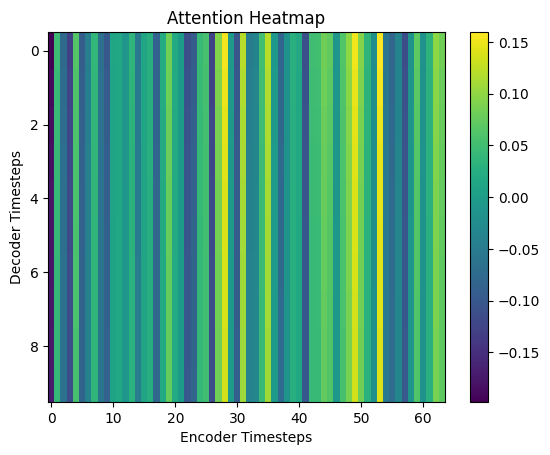

In [ ]:
# LAB 6: Seq2Seq with Attention + Heatmap (FIXED)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Attention, Concatenate
from tensorflow.keras.models import Model

# Dummy dataset
vocab_size = 50
max_len = 10
num_samples = 1000

encoder_input_data = np.random.randint(1, vocab_size, size=(num_samples, max_len))
decoder_input_data = np.random.randint(1, vocab_size, size=(num_samples, max_len))
decoder_output_data = np.random.randint(1, vocab_size, size=(num_samples, max_len))

# Encoder
encoder_inputs = Input(shape=(max_len,))
enc_emb = Embedding(vocab_size, 64)(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(64, return_sequences=True, return_state=True)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(max_len,))
dec_emb = Embedding(vocab_size, 64)(decoder_inputs)
decoder_lstm = LSTM(64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# Attention
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# FIX: use Concatenate instead of tf.concat
concat = Concatenate(axis=-1)([decoder_outputs, attention_output])

# Dense
decoder_dense = Dense(vocab_size, activation='softmax')
final_outputs = decoder_dense(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], final_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Train
print("Training model...")
model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_output_data,
    epochs=3,
    batch_size=32
)

# ===== HEATMAP =====

# Build separate attention model (IMPORTANT FIX)
attention_model = Model(
    inputs=[encoder_inputs, decoder_inputs],
    outputs=attention_output
)

sample_encoder = encoder_input_data[0:1]
sample_decoder = decoder_input_data[0:1]

attention_weights = attention_model.predict([sample_encoder, sample_decoder])

# Plot heatmap
plt.figure()
plt.imshow(attention_weights[0], aspect='auto')
plt.colorbar()
plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")
plt.show()